In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 65.1 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(



--- Welcome to DNA Sequence Analyzer ---

Enter first sequence: ATATATATATAGCGCGTGCATGC
Enter ssecond sequence: ATAGCGCTGACGA
Your sequences are: 
 ATATATATATAGCGCGTGCATGC 
 ATAGCGCTGACGA 

Do you want to combine sequences for analysis? (yes/no): yes
Please choose an option: 
1.Calculate GC Content

    2.Find Reverse Complement
3.Transcribe DNA to RNA
4.Translate DNA to Protein

    5.Plot Base Composition
6.Align Sequences (global/local)

    7.Run Full DNA Analyzer (All Steps)
0.Exit:
1

GC Content:  44.44444444444444 

Please choose an option: 
1.Calculate GC Content

    2.Find Reverse Complement
3.Transcribe DNA to RNA
4.Translate DNA to Protein

    5.Plot Base Composition
6.Align Sequences (global/local)

    7.Run Full DNA Analyzer (All Steps)
0.Exit:
2

Reverse Complement:  TCGTCAGCGCTATGCATGCACGCGCTATATATATAT 

Please choose an option: 
1.Calculate GC Content

    2.Find Reverse Complement
3.Transcribe DNA to RNA
4.Translate DNA to Protein

    5.Plot Base Composition
6.Ali

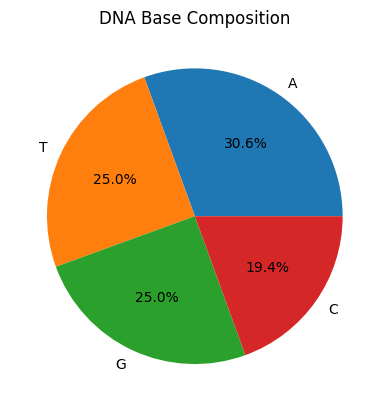

Please choose an option: 
1.Calculate GC Content

    2.Find Reverse Complement
3.Transcribe DNA to RNA
4.Translate DNA to Protein

    5.Plot Base Composition
6.Align Sequences (global/local)

    7.Run Full DNA Analyzer (All Steps)
0.Exit:
6
Choose alignment type (global/local): global
ATATATATATAGCGCGTGCATGC--
        ||||||| || |  |  
--------ATAGCGC-TG-A--CGA
  Score=11



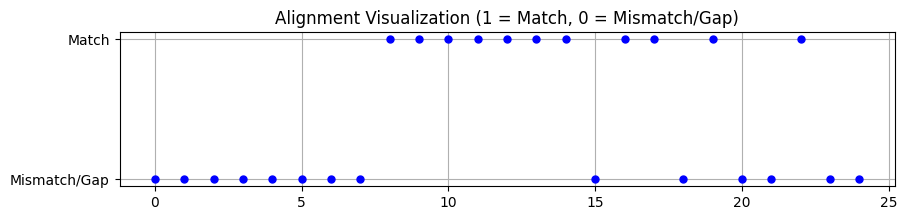

Please choose an option: 
1.Calculate GC Content

    2.Find Reverse Complement
3.Transcribe DNA to RNA
4.Translate DNA to Protein

    5.Plot Base Composition
6.Align Sequences (global/local)

    7.Run Full DNA Analyzer (All Steps)
0.Exit:
7

GC Content: 44.44%

Reverse Complement:
TCGTCAGCGCTATGCATGCACGCGCTATATATATAT

RNA Transcription:
AUAUAUAUAUAGCGCGUGCAUGCAUAGCGCUGACGA

Protein Translation:
IYI_RVHA_R_R


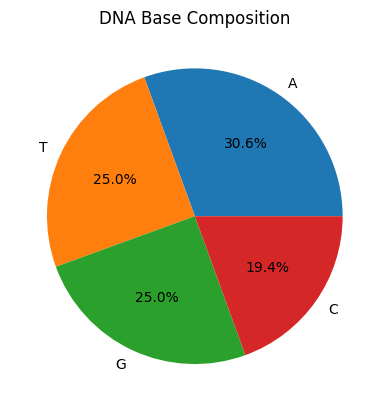


Choose alignment type (global/local): local
9 ATAGCGCGTGCATGC
  ||||||| || |  |
1 ATAGCGC-TG-A--C
  Score=11



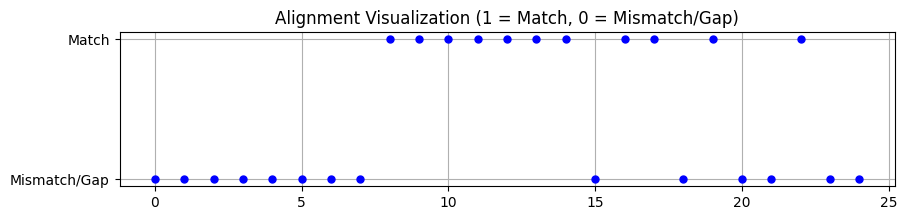

Please choose an option: 
1.Calculate GC Content

    2.Find Reverse Complement
3.Transcribe DNA to RNA
4.Translate DNA to Protein

    5.Plot Base Composition
6.Align Sequences (global/local)

    7.Run Full DNA Analyzer (All Steps)
0.Exit:
0

Exiting program. Goodbye!


In [ ]:
# dna_analyzer_project.py

import matplotlib.pyplot as plt
from Bio.Seq import Seq
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

# -------- Functions -------- #

def validate_dna(seq):
    for base in seq:
      if base not in ['A','T','C','G']:
         return False
    return True

def calculate_gc_content(com_seq):
  gc=com_seq.count('G')+com_seq.count('C')
  return gc/len(com_seq)*100

def reverse_complement(com_seq):
  complement={'A':'T','T':'A','G':'C','C':'G'}
  rev_comp=''.join(complement[base] for base in reversed(com_seq))
  return rev_comp


def transcribe_dna(com_seq):
  rna_seq=com_seq.replace('T','U')
  return rna_seq

def translate_dna(com_seq):
    codon_table = {
        'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',
        'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
        'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
        'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
        'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
        'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
        'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
        'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
        'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V',
        'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
        'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
        'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
        'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
        'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
        'TAC':'Y', 'TAT':'Y', 'TAA':'_', 'TAG':'_',
        'TGC':'C', 'TGT':'C', 'TGA':'_', 'TGG':'W',
    }
    protein = ""
    for i in range(0, len(com_seq) - 2, 3):
        codon = com_seq[i:i+3]
        amino_acid = codon_table.get(codon, '?')
        protein += amino_acid
    return protein
    print(translate_dna(com_seq))


def plot_base_composition(com_seq):
    seq = com_seq.upper()
    a_count = seq.count('A')
    t_count = seq.count('T')
    g_count = seq.count('G')
    c_count = seq.count('C')
    labels = ['A', 'T', 'G', 'C']
    sizes = [a_count, t_count, g_count, c_count]
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.title("DNA Base Composition")
    plt.show()

def align_sequences(seq1, seq2, alignment_type):
    seq1 = seq1.upper()
    seq2 = seq2.upper()

    if alignment_type == "global":
        alignments = pairwise2.align.globalxx(seq1, seq2)
    else:
        alignments = pairwise2.align.localxx(seq1, seq2)

    best_alignment = alignments[0]
    aligned_seq1, aligned_seq2, score, start, end = best_alignment

    print(format_alignment(*best_alignment))

    # Plotting matches
    matches = []
    positions = []

    for idx, (base1, base2) in enumerate(zip(aligned_seq1, aligned_seq2)):
        if base1 == base2 and base1 != '-':
            matches.append(1)
        else:
            matches.append(0)
        positions.append(idx)
#Plot

    plt.figure(figsize=(10,2))
    plt.plot(positions, matches, 'bo', markersize=5)
    plt.title("Alignment Visualization (1 = Match, 0 = Mismatch/Gap)")
    plt.yticks([0,1], labels=["Mismatch/Gap", "Match"])
    plt.grid(True)
    plt.show()

# -------- Main Program -------- #

if __name__ == "__main__":
    print("\n--- Welcome to DNA Sequence Analyzer ---\n")
    seq_1=input("Enter first sequence: ").upper().replace(" ","").replace("\n","")
    seq_2= input("Enter ssecond sequence: ").upper().replace(" ","").replace("\n","")
    print("Your sequences are: \n",seq_1,"\n",seq_2,"\n")
    combine_choice = input("Do you want to combine sequences for analysis? (yes/no): ").lower()

if combine_choice == "yes":
    com_seq = seq_1 + seq_2
else:
    selected = input("Which sequence do you want to analyze? (1 or 2): ")
    if selected == "1":
        com_seq = seq_1
    else:
        com_seq = seq_2

    while True:
        print("\nChoose an option:")
        print("1. Calculate GC Content")
        print("2. Find Reverse Complement")
        print("3. Transcribe DNA to RNA")
        print("4. Translate DNA to Protein")
        print("5. Plot Base Composition")
        print("6. Align Sequences (Global or Local)")
        print("7. Run Full DNA Analyzer (All Steps)")
        print("0. Exit\n")

 # After combine_choice
while True:
    choice = input("""Please choose an option: \n1.Calculate GC Content\n
    2.Find Reverse Complement\n3.Transcribe DNA to RNA\n4.Translate DNA to Protein\n
    5.Plot Base Composition\n6.Align Sequences (global/local)\n
    7.Run Full DNA Analyzer (All Steps)\n0.Exit:\n""")

    if choice == "1":
        print("\nGC Content: ",calculate_gc_content(com_seq),"\n")

    elif choice == "2":
        print("\nReverse Complement: ",reverse_complement(com_seq),"\n")

    elif choice == "3":
        print("\nTranscribe DNA: ",transcribe_dna(com_seq),"\n")

    elif choice == "4":
        print("\nTranslate DNA",translate_dna(com_seq),"\n")

    elif choice == "5":
        plot_base_composition(com_seq)

    elif choice == "6":
        alignment_type = input("Choose alignment type (global/local): ").lower()
        align_sequences(seq_1, seq_2, alignment_type)

    elif choice == '7':
         print(f"\nGC Content: {calculate_gc_content(com_seq):.2f}%")
         print(f"\nReverse Complement:\n{reverse_complement(com_seq)}")
         print(f"\nRNA Transcription:\n{transcribe_dna(com_seq)}")
         print(f"\nProtein Translation:\n{translate_dna(com_seq)}")
         plot_base_composition(com_seq)
         alignment_choice = input("\nChoose alignment type (global/local): ").lower()
         align_sequences(seq_1,seq_2, alignment_type=alignment_choice)

    elif choice == '0':
            print("\nExiting program. Goodbye!")
            break

    else:
            print("\nInvalid choice. Please enter a number between 0 and 7.")
